In [1]:
!pip install torch torchvision albumentations pycocotools -q


In [3]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torchvision.models.segmentation as models
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.datasets import CocoDetection
from google.colab import drive
from tqdm import tqdm

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Paths
data_root = "/content/drive/MyDrive/Colab Notebooks/VisionExtraction/val2017"
ann_file  = "/content/drive/MyDrive/Colab Notebooks/VisionExtraction/annotations/instances_val2017.json"
model_path = "/content/drive/MyDrive/Colab Notebooks/VisionExtraction/Projects/best_model11.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)


Mounted at /content/drive
✅ Using device: cuda


In [4]:
class CocoSegmentation(torch.utils.data.Dataset):
    def __init__(self, root, annFile, transforms=None):
        self.dataset = CocoDetection(root, annFile)
        self.transforms = transforms

    def __getitem__(self, idx):
        img, target = self.dataset[idx]
        img = np.array(img)

        mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        for obj in target:
            rle = self.dataset.coco.annToMask(obj)
            mask = np.maximum(mask, rle)
        mask = mask.astype(np.float32)

        if self.transforms:
            augmented = self.transforms(image=img, mask=mask)
            img, mask = augmented["image"], augmented["mask"]

        return img, mask.long()

    def __len__(self):
        return len(self.dataset)

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

val_dataset = CocoSegmentation(data_root, ann_file, transforms=val_transform)


loading annotations into memory...
Done (t=3.04s)
creating index...
index created!


In [5]:
model = models.deeplabv3_resnet50(pretrained=False)
model.classifier[4] = nn.Conv2d(256, 2, kernel_size=1)

state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict, strict=False)

model.to(device)
model.eval()
print("✅ Model loaded successfully")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]


✅ Model loaded successfully


In [6]:
import cv2

def denormalize(img_tensor, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]):
    img = img_tensor.clone().cpu()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    return np.clip(img.permute(1,2,0).numpy(), 0, 1)

def run_inference_on_image(image_path):
    # Load and preprocess
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- Resize image to match model input ---
    img_resized = cv2.resize(img, (256, 256))

    transformed = val_transform(image=img, mask=np.zeros(img.shape[:2], dtype=np.uint8))
    img_tensor = transformed["image"].unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        output = model(img_tensor)["out"]
    pred = torch.argmax(output, dim=1)[0].cpu().numpy()

    # Create black background and keep only object
    object_only = np.zeros_like(img_resized)
    object_only[pred == 1] = img_resized[pred == 1]

    # Visualization
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Original (Resized)")

    plt.subplot(1,2,2)
    plt.imshow(object_only)
    plt.axis('off')
    plt.title("Predicted Object")
    plt.show()


FileUpload(value={}, accept='image/*', description='Upload', multiple=True)

📷 Running inference on download (10).jpeg ...


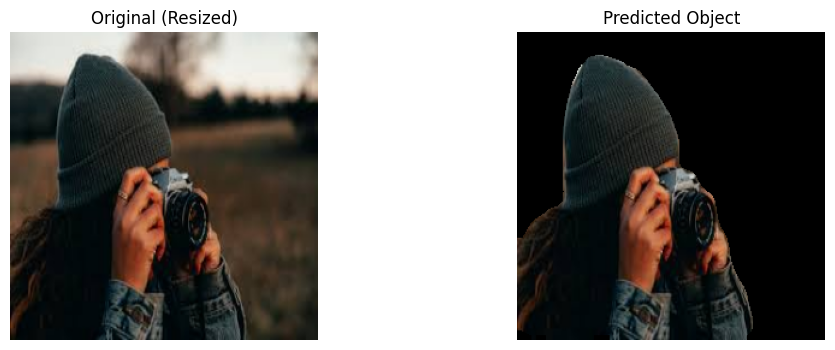

📷 Running inference on images (6).jpeg ...


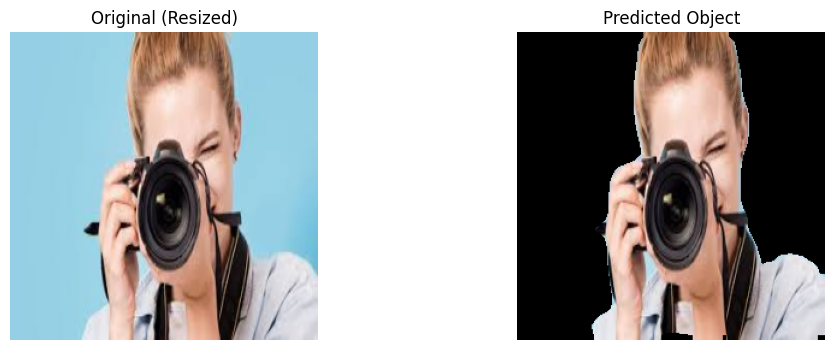

📷 Running inference on images (11).jpeg ...


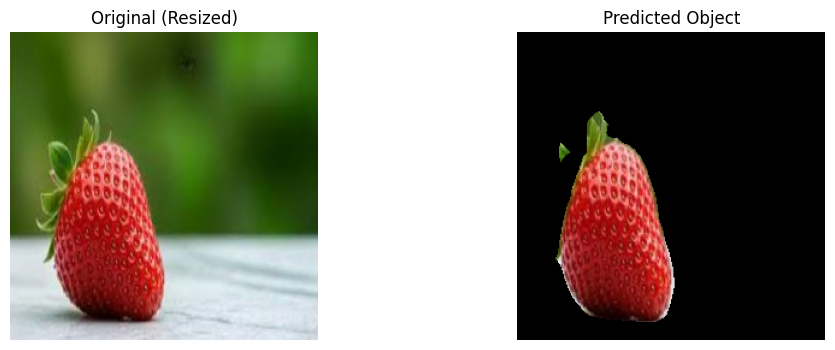

📷 Running inference on images (10).jpeg ...


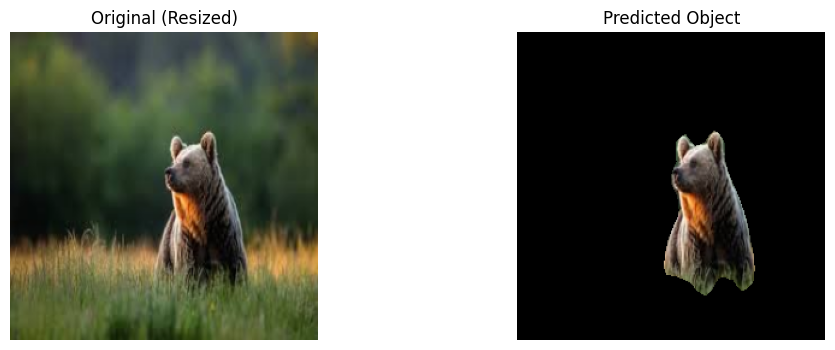

📷 Running inference on images (21).jpeg ...


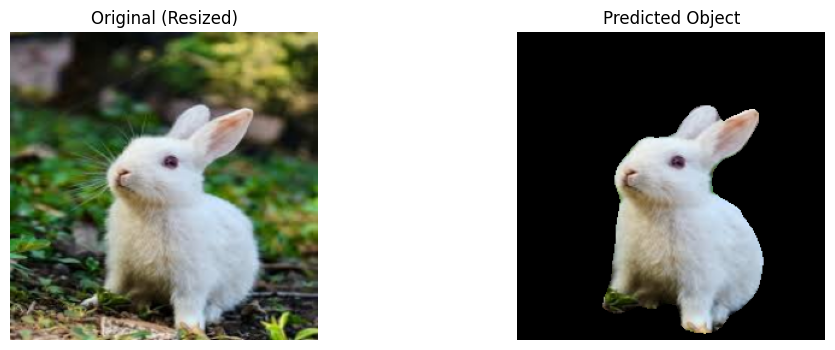

📷 Running inference on images (19).jpeg ...


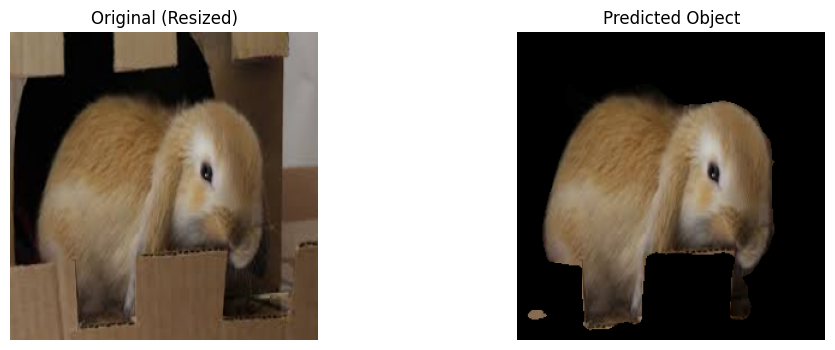

In [7]:
from google.colab import files
import ipywidgets as widgets
from IPython.display import display

# Allow multiple image uploads
upload_button = widgets.FileUpload(accept='image/*', multiple=True)

def on_upload_change(change):
    if upload_button.value:
        for file_info in upload_button.value.values():
            file_name = file_info['metadata']['name']
            with open(file_name, "wb") as f:
                f.write(file_info['content'])
            print(f"📷 Running inference on {file_name} ...")
            run_inference_on_image(file_name)

upload_button.observe(on_upload_change, names='value')
display(upload_button)
